# 🛰️ Clustering No Supervisado — Presa Quebrada Honda | Sentinel-2 L2A

**Diferencia respecto al pipeline de la Presa 1:**
La imagen es un recorte rectangular que incluye terreno exterior a la presa.
Se agrega una etapa previa de **delimitación automática del TSF** usando índices especializados
para separar el dominio de la presa del terreno natural árido circundante.

**Índices clave para la delimitación (entorno árido):**
- IOR (Iron Oxide Ratio = B04/B02): relaves procesados tienen MENOR IOR que roca natural con óxidos superficiales
- NDTIFe = (B04−B03)/(B04+B03): terreno exterior árido tiene NDTIFe más alto que el material de relave
- NDVI < 0.18: excluye vegetación

**Semilla del region growing:** centroide de la imagen (fila=rows//2, col=cols//2),
válido siempre que la presa esté centrada en el recorte.

---
### Bandas requeridas (todas a la misma resolución)
| Banda | Descripción | Rol |
|-------|-------------|-----|
| B01 | Aerosol costero | Exploración espectral |
| B02 | Azul | Dominio TSF, BSI, IOR |
| B03 | Verde | NDWI, MNDWI, NDTIFe |
| B04 | Rojo | BSI, NDTIFe, IOR, feature clustering |
| B05 | Red Edge 1 | NDRE, exploración mineralogía |
| B06 | Red Edge 2 | MNTI (índice específico relaves) |
| B07 | Red Edge 3 | Exploración mineralogía |
| B08 | NIR | Detector de agua (O'Donovan 2022) |
| B8A | NIR estrecho | CMI, FMI, NDRE |
| B09 | Vapor de agua | Exploración espectral |
| B11 | SWIR-1 | Feature principal clustering (Schimmer 2008) |
| B12 | SWIR-2 | Feature principal clustering (Schimmer 2008) |

**Referencias:**
- Schimmer (2008): features SWIR para relaves
- O'Donovan et al. (2022): detección del pond con NDWI + B08
- Hao et al. (2019): MNTI con bandas Red Edge
- Zhang et al. (2018): IOR y NDTIFe para discriminar relaves de roca natural

## Celda 1 — Instalación de dependencias

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 1 — Instalación
# ─────────────────────────────────────────────────────────────────────────────
!pip install tifffile --quiet
print('✅ Dependencias listas')

✅ Dependencias listas


## Celda 2 — Importaciones

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2 — Importaciones
# ─────────────────────────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import tifffile
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.ndimage import (
    label as scipy_label,
    binary_fill_holes,
    binary_dilation,
    binary_opening,
    binary_closing
)

print(f'✅ Importaciones OK | NumPy {np.__version__} | Matplotlib {matplotlib.__version__}')

✅ Importaciones OK | NumPy 2.0.2 | Matplotlib 3.10.0


## Celda 3 — Carga de bandas

**► AJUSTA** `DATA_DIR` y los nombres en `BAND_FILES` según tus archivos.

Sube las 12 bandas al panel izquierdo de Colab (ícono 📁) o monta Google Drive.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 3 — Rutas y carga de bandas
#
# ► AJUSTA DATA_DIR y los nombres de BAND_FILES según tus archivos.
# ─────────────────────────────────────────────────────────────────────────────

DATA_DIR = '/content/'   # ← carpeta donde subiste los .tiff

# ► AJUSTA la fecha y el prefijo exacto de tus archivos
PREFIX   = '2026-03-21-00_00_2026-03-21-23_59_Sentinel-2_L2A_'

BAND_FILES = {
    'B01': PREFIX + 'B01_(Raw).tiff',
    'B02': PREFIX + 'B02_(Raw).tiff',
    'B03': PREFIX + 'B03_(Raw).tiff',
    'B04': PREFIX + 'B04_(Raw).tiff',
    'B05': PREFIX + 'B05_(Raw).tiff',
    'B06': PREFIX + 'B06_(Raw).tiff',
    'B07': PREFIX + 'B07_(Raw).tiff',
    'B08': PREFIX + 'B08_(Raw).tiff',
    'B8A': PREFIX + 'B8A_(Raw).tiff',
    'B09': PREFIX + 'B09_(Raw).tiff',
    'B11': PREFIX + 'B11_(Raw).tiff',
    'B12': PREFIX + 'B12_(Raw).tiff',
}

# ─── Carga ────────────────────────────────────────────────────────────────────
bands = {}
for name, fname in BAND_FILES.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f'❌ No encontrado: {path}')
        continue
    arr = tifffile.imread(path).astype(np.float32)
    # Escalar a reflectancia 0–1 si viene en formato entero (0–10000)
    if arr.max() > 1.0:
        arr = arr / 10000.0
        print(f'  {name}: escalado ÷10000')
    bands[name] = arr
    print(f'✅ {name}: shape={arr.shape}  min={arr.min():.4f}  max={arr.max():.4f}')

# ─── Remuestreo si alguna banda tiene resolución distinta ─────────────────────
ref_shape = bands['B02'].shape
for name in list(bands.keys()):
    if bands[name].shape != ref_shape:
        from scipy.ndimage import zoom as ndimage_zoom
        zf = (ref_shape[0]/bands[name].shape[0], ref_shape[1]/bands[name].shape[1])
        bands[name] = ndimage_zoom(bands[name], zf, order=1).astype(np.float32)
        print(f'  {name}: remuestreado a {ref_shape}')

ROWS, COLS = ref_shape
print(f'\nDimensiones: {ROWS} × {COLS} px  |  '
      f'Área total tile: {ROWS * COLS * 0.01:.0f} ha')

# Referencias directas a las bandas más usadas
B02=bands['B02']; B03=bands['B03']; B04=bands['B04']
B06=bands['B06']; B08=bands['B08']; B8A=bands['B8A']
B11=bands['B11']; B12=bands['B12']
eps = 1e-9

✅ B01: shape=(772, 1026)  min=0.0347  max=0.3607
✅ B02: shape=(772, 1026)  min=0.0269  max=0.4953
✅ B03: shape=(772, 1026)  min=0.0485  max=0.5539
✅ B04: shape=(772, 1026)  min=0.0399  max=0.5945
✅ B05: shape=(772, 1026)  min=0.0337  max=0.5218
✅ B06: shape=(772, 1026)  min=0.0190  max=0.5345
✅ B07: shape=(772, 1026)  min=0.0257  max=0.5282
✅ B08: shape=(772, 1026)  min=0.0267  max=0.5893
✅ B8A: shape=(772, 1026)  min=0.0217  max=0.5263
✅ B09: shape=(772, 1026)  min=0.0161  max=0.4474
✅ B11: shape=(772, 1026)  min=0.0160  max=0.5680
✅ B12: shape=(772, 1026)  min=0.0148  max=0.5191

Dimensiones: 772 × 1026 px  |  Área total tile: 7921 ha


## Celda 4 — Índices espectrales

Se calculan todos los índices necesarios para la delimitación del TSF y el clustering de la playa.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 4 — Cálculo de índices espectrales
#
# Índices para DETECCIÓN DEL TSF (discriminan relaves de terreno árido):
#   IOR     = B04/B02  — Iron Oxide Ratio
#             Relaves procesados tienen MENOR IOR que roca natural con óxidos
#             Criterio TSF: IOR < 1.65  (calibrado para Quebrada Honda)
#             Referencia: Zhang et al. (2018)
#
#   NDTIFe  = (B04−B03)/(B04+B03)  — Normalized Difference Tailing Iron
#             Terreno exterior árido tiene NDTIFe MÁS ALTO que relave
#             Criterio TSF: NDTIFe < 0.10  (calibrado para Quebrada Honda)
#             Referencia: Schimmer (2008), Zhang et al. (2018)
#
# Índices para DETECCIÓN DEL POND:
#   NDWI    = (B03−B08)/(B03+B08)  — McFeeters (1996)
#
# Índices para CLUSTERING DE PLAYA:
#   MNDWI   = (B03−B11)/(B03+B11)  — Xu (2006)
#   BSI     = ((B11+B04)−(B08+B02))/((B11+B04)+(B08+B02))  — Rikimaru et al. (2002)
#   MNTI    = (B06−B11)/(B06+B11)  — Hao et al. (2019), Schimmer (2008)
#   NDVI    = (B08−B04)/(B08+B04)  — Rouse et al. (1974)
# ─────────────────────────────────────────────────────────────────────────────
B08_band = bands['B08']

# Índices de delimitación del TSF
IOR    = B04 / (B02 + eps)
NDTIFe = (B04 - B03) / (B04 + B03 + eps)
NDVI   = (B08_band - B04) / (B08_band + B04 + eps)

# Índice de agua
NDWI   = (B03 - B08_band) / (B03 + B08_band + eps)

# Índices de playa
MNDWI  = (B03 - B11) / (B03 + B11 + eps)
BSI    = ((B11 + B04) - (B08_band + B02)) / ((B11 + B04) + (B08_band + B02) + eps)
MNTI   = (B06 - B11) / (B06 + B11 + eps)   # Red Edge vs SWIR — específico para relaves
SWIR_r = B12 / (B11 + eps)

# Centroide de la imagen = semilla del TSF (la presa está centrada)
CY, CX = ROWS // 2, COLS // 2

print('Valores en el centroide (interior de la presa):')
for name, idx in [('IOR',IOR),('NDTIFe',NDTIFe),('NDVI',NDVI),
                   ('NDWI',NDWI),('MNDWI',MNDWI),('BSI',BSI),('MNTI',MNTI)]:
    print(f'  {name:10s}: {idx[CY,CX]:+.4f}')
print(f'\nCentroide: fila={CY}, col={CX}')

Valores en el centroide (interior de la presa):
  IOR       : +0.8212
  NDTIFe    : -0.0948
  NDVI      : -0.4721
  NDWI      : +0.5427
  MNDWI     : +0.8063
  BSI       : -0.1650
  MNTI      : +0.5476

Centroide: fila=386, col=513


## Celda 4b — Georreferenciación: coordenadas del centroide

Lee el **affine transform** y el **CRS** embebidos en el GeoTIFF de B02
(todos los TIFFs de Copernicus Browser comparten la misma georreferencia).
Convierte el centroide `(CY, CX)` a **UTM** y **WGS84 lat/lon**.

- Usa `rasterio` solo para leer metadatos — el pipeline de píxeles no cambia.
- Si `rasterio` no está instalado la celda lo instala automáticamente.
- El centroide `(CY, CX)` ya fue calculado en la Celda 4.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 4b — Coordenadas geoespaciales del centroide del TSF
#
# Flujo:
#   1. Leer affine transform + CRS del GeoTIFF (solo metadatos, no píxeles)
#   2. (fila=CY, col=CX) → (X_utm, Y_utm)  usando el affine transform
#   3. (X_utm, Y_utm) → (lat, lon)          usando pyproj
#
# Nota: el centroide de píxel está en el CENTRO del píxel, no en su esquina.
#       Por eso se suma 0.5 antes de aplicar el transform.
# ─────────────────────────────────────────────────────────────────────────────

# ── Instalación silenciosa si no están disponibles ───────────────────────────
import importlib, subprocess, sys

def _ensure(pkg, import_as=None):
    mod = import_as or pkg
    if importlib.util.find_spec(mod) is None:
        print(f'  Instalando {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    return importlib.import_module(mod)

rasterio = _ensure('rasterio')
pyproj   = _ensure('pyproj')
from pyproj import Transformer

# ── Leer metadatos del GeoTIFF de B02 ────────────────────────────────────────
tiff_path = os.path.join(DATA_DIR, BAND_FILES['B02'])

with rasterio.open(tiff_path) as src:
    transform = src.transform   # affine.Affine: mapea (col, row) → (X, Y) en el CRS del archivo
    crs       = src.crs         # sistema de referencia de coordenadas (ej. EPSG:32718)
    width_px  = src.width
    height_px = src.height

print(f'CRS del archivo : {crs}')
print(f'EPSG            : {crs.to_epsg()}')
print(f'Dimensiones     : {width_px} × {height_px} px')
print(f'Resolución      : {abs(transform.a):.1f} m/px  ×  {abs(transform.e):.1f} m/px')
print(f'Origen (X, Y)   : ({transform.c:.2f}, {transform.f:.2f})')

# ── (fila, col) → (X, Y) en la proyección del archivo ───────────────────────
# El centroide del píxel está en (col + 0.5, row + 0.5) en coordenadas de píxel.
col_c = CX + 0.5
row_c = CY + 0.5

X_utm = transform.c + col_c * transform.a   # X = origen_X + col × ancho_pixel
Y_utm = transform.f + row_c * transform.e   # Y = origen_Y + row × alto_pixel (negativo)

print(f'\nCentroide en píxeles : fila={CY}, col={CX}')
print(f'Centroide en UTM     : X={X_utm:.2f} m,  Y={Y_utm:.2f} m')

# ── UTM → WGS84 lat/lon ──────────────────────────────────────────────────────
epsg_src = crs.to_epsg()
t = Transformer.from_crs(f'EPSG:{epsg_src}', 'EPSG:4326', always_xy=True)
lon, lat = t.transform(X_utm, Y_utm)

print(f'\n{"═"*52}')
print(f'  COORDENADAS DEL CENTROIDE — Presa Quebrada Honda')
print(f'  {"─"*50}')
print(f'  UTM (EPSG:{epsg_src})')
print(f'    Este  (X) : {X_utm:>14.2f} m')
print(f'    Norte (Y) : {Y_utm:>14.2f} m')
print(f'  WGS84 (EPSG:4326)')
print(f'    Latitud   : {lat:>14.8f} °')
print(f'    Longitud  : {lon:>14.8f} °')
print(f'  Google Maps : https://maps.google.com/?q={lat:.6f},{lon:.6f}')
print(f'{"═"*52}')

# Guardar para uso posterior en el pipeline
CENTROIDE_UTM  = (X_utm, Y_utm)
CENTROIDE_WGS84 = (lat, lon)
EPSG_ARCHIVO   = epsg_src
GEO_TRANSFORM  = transform
GEO_CRS        = crs


## Celda 5 — Paso 1: Delimitación automática del TSF

Estrategia: region growing desde el centroide usando IOR + NDTIFe + NDVI como criterio de pertenencia.
Los umbrales fueron calibrados para Quebrada Honda comparando el centroide (interior presa)
vs la esquina superior izquierda (exterior). Ajustar si la separabilidad en una nueva presa es distinta.

Píxeles que pasan el criterio TSF: 245,750 = 2458 ha
Centroide pasa el criterio: True (debe ser True)
  Region growing convergió en iteración 634
Region growing bruto : 2378 ha
TSF final (limpio)   : 2463 ha


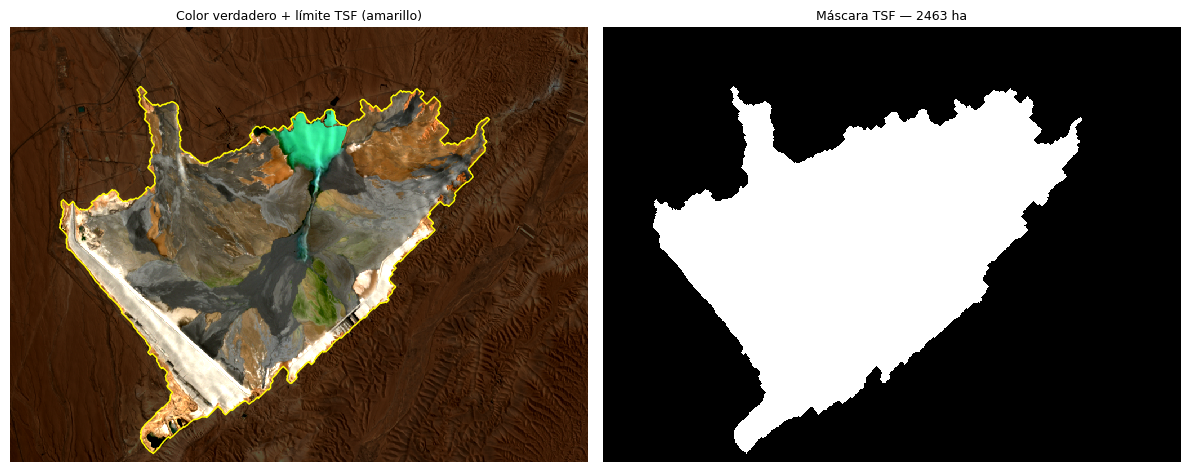

✅ Máscara TSF guardada: tsf_mask.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — Delimitación automática del TSF
#
# Criterio de pertenencia al TSF (calibrado para Quebrada Honda):
#   IOR     < 1.65   — relaves tienen bajo Iron Oxide Ratio
#   NDTIFe  < 0.10   — relaves tienen bajo índice de óxido de hierro
#   NDVI    < 0.18   — sin vegetación densa
#
# ► Si para una nueva presa el centroide NO pasa el criterio (crit_tsf[CY,CX] == False),
#   ajustar los umbrales de IOR_TH, NDTIFe_TH y NDVI_TH hasta que pase.
#   Herramienta de diagnóstico: calcular la distancia de Cohen d entre
#   una zona interior (±100px del centroide) y una zona exterior (bordes de imagen).
# ─────────────────────────────────────────────────────────────────────────────

IOR_TH    = 1.65   # ← AJUSTA si es necesario
NDTIFe_TH = 0.10   # ← AJUSTA si es necesario
NDVI_TH   = 0.18   # ← AJUSTA si es necesario

crit_tsf = (IOR < IOR_TH) & (NDTIFe < NDTIFe_TH) & (NDVI < NDVI_TH)

print(f'Píxeles que pasan el criterio TSF: {crit_tsf.sum():,} = {crit_tsf.sum()*0.01:.0f} ha')
print(f'Centroide pasa el criterio: {crit_tsf[CY, CX]} (debe ser True)')

if not crit_tsf[CY, CX]:
    print('⚠️  El centroide NO pasa el criterio. Ajusta IOR_TH, NDTIFe_TH o NDVI_TH.')
    print(f'   IOR en centroide    = {IOR[CY,CX]:.4f}  (umbral: < {IOR_TH})')
    print(f'   NDTIFe en centroide = {NDTIFe[CY,CX]:.4f}  (umbral: < {NDTIFe_TH})')
    print(f'   NDVI en centroide   = {NDVI[CY,CX]:.4f}  (umbral: < {NDVI_TH})')
else:
    # ── Region growing desde el centroide ────────────────────────────────────
    tsf_grown = np.zeros((ROWS, COLS), dtype=bool)
    tsf_grown[CY, CX] = True
    for iteration in range(800):
        exp = np.zeros_like(tsf_grown)
        exp[1:,:]  |= tsf_grown[:-1, :]
        exp[:-1,:] |= tsf_grown[1:,  :]
        exp[:,1:]  |= tsf_grown[:, :-1]
        exp[:,:-1] |= tsf_grown[:, 1: ]
        new = exp & crit_tsf & ~tsf_grown
        if new.sum() == 0:
            print(f'  Region growing convergió en iteración {iteration + 1}')
            break
        tsf_grown |= new

    # ── Morfología: cerrar brechas + rellenar + limpiar bordes ────────────────
    tsf_closed = binary_closing(tsf_grown,  iterations=8)   # sella brechas pequeñas
    tsf_filled = binary_fill_holes(tsf_closed)               # rellena huecos internos
    tsf_open   = binary_opening(tsf_filled,  iterations=3)   # limpia bordes irregulares
    tsf_mask   = binary_fill_holes(tsf_open)                 # relleno final

    print(f'Region growing bruto : {tsf_grown.sum()*0.01:.0f} ha')
    print(f'TSF final (limpio)   : {tsf_mask.sum()*0.01:.0f} ha')

    # Visualización rápida
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    rgb = np.dstack([B04, B03, B02])
    p2, p98 = np.percentile(rgb, [2, 98])
    rgb_d = np.clip((rgb - p2) / (p98 - p2 + eps), 0, 1)
    rgb_ext = rgb_d.copy()
    rgb_ext[~tsf_mask] = rgb_ext[~tsf_mask] * 0.35
    axes[0].imshow(rgb_ext, interpolation='nearest')
    axes[0].contour(tsf_mask, levels=[0.5], colors=['yellow'], linewidths=1)
    axes[0].set_title('Color verdadero + límite TSF (amarillo)', fontsize=9)
    axes[0].axis('off')
    axes[1].imshow(tsf_mask, cmap='gray', interpolation='nearest')
    axes[1].set_title(f'Máscara TSF — {tsf_mask.sum()*0.01:.0f} ha', fontsize=9)
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('tsf_mask.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ Máscara TSF guardada: tsf_mask.png')

## Celda 6 — Paso 2: Detección del pond

Igual que en la Presa 1 pero restringido al dominio del TSF.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 6 — Detección del pond (agua) dentro del TSF
#
# Igual al pipeline de la Presa 1.
# O'Donovan et al. (2022): criterio dual NDWI + B08.
# ─────────────────────────────────────────────────────────────────────────────

# Paso A: núcleo estricto (agua pura, sin duda)
water_core   = tsf_mask & (NDWI > 0.0) & (B08_band < 0.05)
labeled_w, _ = scipy_label(water_core)
sizes_w      = np.bincount(labeled_w.ravel()); sizes_w[0] = 0

# Usar las 3 componentes más grandes como semillas (puede haber varios ponds)
top3      = np.argsort(sizes_w)[::-1][:3]
seed_mask = np.zeros_like(water_core, dtype=bool)
for cid in top3:
    if sizes_w[cid] > 50:   # mínimo 50 px para ser considerado pond real
        seed_mask |= (labeled_w == cid)

print(f'Núcleo de agua (NDWI>0 & B08<0.05): {water_core.sum():,} px = {water_core.sum()*0.01:.1f} ha')
print(f'Componentes de agua detectadas: {(sizes_w > 0).sum()}')
for i, cid in enumerate(top3[:3]):
    if sizes_w[cid] > 0:
        print(f'  Comp {i+1}: {sizes_w[cid]:,} px = {sizes_w[cid]*0.01:.1f} ha')

# Paso B: region growing — captura bordes de mezcla espectral
permissive  = tsf_mask & (NDWI > -0.15) & (B08_band < 0.12)
water_grown = seed_mask.copy()
for _ in range(50):
    exp = np.zeros_like(water_grown)
    exp[1:,:]  |= water_grown[:-1, :]; exp[:-1,:] |= water_grown[1:,  :]
    exp[:,1:]  |= water_grown[:, :-1]; exp[:,:-1] |= water_grown[:, 1: ]
    new = exp & permissive & ~water_grown
    if new.sum() == 0: break
    water_grown |= new

# Paso C: fill_holes — sella huecos completamente rodeados por agua
water_final = binary_fill_holes(water_grown) & tsf_mask

print(f'\nAgua final (pond completo): {water_final.sum():,} px = {water_final.sum()*0.01:.1f} ha')

# Verificar que toda el agua esté dentro del TSF
agua_en_tsf = (water_final & tsf_mask).sum() / max(water_final.sum(), 1)
print(f'Agua dentro del TSF: {100*agua_en_tsf:.1f}%  (debe ser 100%)')
if agua_en_tsf < 0.99:
    print('⚠️  Agua fuera del TSF detectada. Revisar la máscara del TSF (Celda 5).')

Núcleo de agua (NDWI>0 & B08<0.05): 6,686 px = 66.9 ha
Componentes de agua detectadas: 14
  Comp 1: 6,144 px = 61.4 ha
  Comp 2: 311 px = 3.1 ha
  Comp 3: 170 px = 1.7 ha

Agua final (pond completo): 10,039 px = 100.4 ha
Agua dentro del TSF: 100.0%  (debe ser 100%)


## Celda 7 — Paso 3: Condicional NoData dentro del pond

Para Quebrada Honda esta celda generalmente **no se activa** porque la imagen no tiene ceros.
Se incluye por robustez en caso de que en otra fecha sí los haya.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 7 — Condicional NoData dentro del pond
#
# Igual al pipeline de la Presa 1.
# Para Quebrada Honda (imagen rectangular sin ceros) esta celda no se activa.
# ─────────────────────────────────────────────────────────────────────────────
all_zero  = np.ones((ROWS, COLS), dtype=bool)  # inicializar en True
for name in ['B02','B03','B04','B08','B11','B12']:
    all_zero &= (bands[name] == 0)

if all_zero.sum() == 0:
    print('✅ Sin píxeles all-zero — condicional NoData no activada')
    pond_nodata = np.zeros((ROWS, COLS), dtype=bool)
else:
    print(f'⚠️  Píxeles all-zero detectados: {all_zero.sum():,} px — aplicando corrección...')
    tsf_dil    = binary_dilation(tsf_mask, iterations=2)
    candidates = all_zero & tsf_dil
    labeled_c, n_c = scipy_label(candidates)
    pond_nodata = np.zeros_like(all_zero, dtype=bool)
    accepted = rejected = 0
    for cid in range(1, n_c + 1):
        comp = labeled_c == cid
        if comp.sum() > 10000: continue   # componente gigante = borde exterior
        nb = binary_dilation(comp, iterations=3) & ~comp & tsf_mask
        if nb.sum() == 0: continue
        ndwi_nb = np.nanmean(NDWI[nb])
        if ndwi_nb > 0.40:   # vecinos = agua clara del pond
            pond_nodata |= comp
            accepted += comp.sum()
        else:
            rejected += comp.sum()
    print(f'  Aceptadas (pond): {accepted:,} px = {accepted*0.01:.1f} ha')
    print(f'  Rechazadas (ext): {rejected:,} px')

water_final = (water_final | pond_nodata) & (tsf_mask | pond_nodata)
print(f'\nAgua total final: {water_final.sum()*0.01:.1f} ha')

✅ Sin píxeles all-zero — condicional NoData no activada

Agua total final: 100.4 ha


## Celda 8 — Paso 4: Features, normalización, PCA y método del codo

Para Quebrada Honda se añade **MNTI** (Hao et al. 2019) como feature adicional
porque las bandas Red Edge aportan información mineralógica relevante en este entorno.

Zona de playa: 236,212 px = 2362 ha
Matriz X_beach: 236,212 píxeles × 7 features
Varianza PCA: [74.9 18.7  4.9  0.9] — total: 99.4%

 k          WCSS       Δ%    Silhouette
──────────────────────────────────────
  2        749360        —        0.5989
  3        406044    45.8%        0.5411
  4        270539    33.4%        0.5440
  5        229307    15.2%        0.4919
  6        199077    13.2%        0.4280


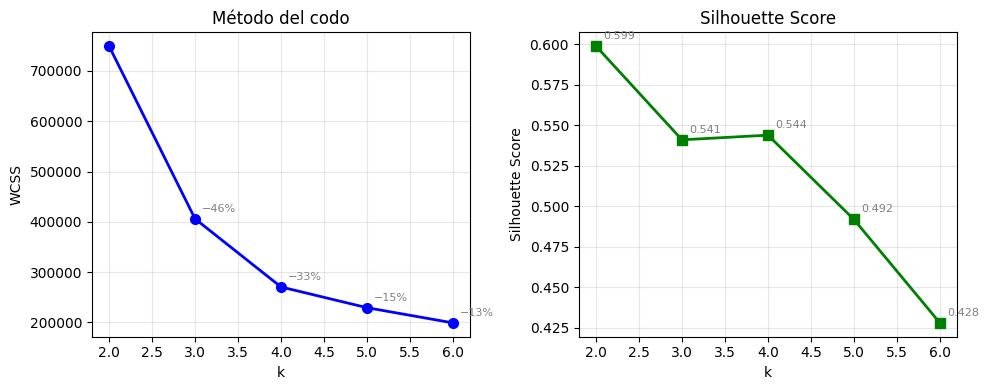

✅ Figura guardada: codo_silhouette.png


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 8 — Clustering de la zona de playa
#
# Features (Schimmer 2008 + Hao et al. 2019):
#   B11, B12     — sensibilidad a humedad y mineralogía (features principales)
#   B04          — contraste entre subtipos de playa
#   MNDWI        — humedad residual (Xu 2006)
#   BSI          — suelo desnudo mineral (Rikimaru et al. 2002)
#   SWIR_ratio   — mineralogía diferencial B12/B11
#   MNTI         — índice específico para relaves con Red Edge (Hao et al. 2019)
#                  Se añade porque Quebrada Honda dispone de bandas B06
# ─────────────────────────────────────────────────────────────────────────────

beach_mask = tsf_mask & ~water_final   # playa = TSF menos agua

# Calcular índices de playa solo sobre la máscara de playa
MNDWI_b = np.where(beach_mask, MNDWI,  np.nan)
BSI_b   = np.where(beach_mask, BSI,    np.nan)
SWIR_b  = np.where(beach_mask, SWIR_r, np.nan)
MNTI_b  = np.where(beach_mask, MNTI,   np.nan)

# Construir matriz X (7 features)
feat_maps = np.stack([B11, B12, B04, MNDWI_b, BSI_b, SWIR_b, MNTI_b], axis=0)
beach_idx = np.where(beach_mask.ravel())[0]
X_beach   = feat_maps.reshape(7, -1).T[beach_idx]

# Reemplazar NaN por la media de cada columna
col_means = np.nanmean(X_beach, axis=0)
nan_pos   = np.isnan(X_beach)
X_beach[nan_pos] = np.take(col_means, np.where(nan_pos)[1])

print(f'Zona de playa: {beach_mask.sum():,} px = {beach_mask.sum()*0.01:.0f} ha')
print(f'Matriz X_beach: {X_beach.shape[0]:,} píxeles × {X_beach.shape[1]} features')

# Normalización + PCA
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_beach)
pca    = PCA(n_components=4, random_state=42)
X_pca  = pca.fit_transform(X_sc)
print(f'Varianza PCA: {np.round(pca.explained_variance_ratio_*100, 1)} — total: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# Método del codo + silhouette
rng     = np.random.default_rng(42)
sil_idx = rng.choice(len(beach_idx), min(5000, len(beach_idx)), replace=False)
X_sil   = X_pca[sil_idx]
wcss_p, sil_p = [], []
K_RANGE = range(2, 7)

print(f'\n{"k":>2}  {"WCSS":>12}  {"Δ%":>7}  {"Silhouette":>12}')
print('─' * 38)
for k in K_RANGE:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbl = km.fit_predict(X_pca)
    wcss_p.append(km.inertia_)
    sil  = silhouette_score(X_sil, lbl[sil_idx])
    sil_p.append(sil)
    drop = f"{100*(wcss_p[-2]-wcss_p[-1])/wcss_p[-2]:.1f}%" if len(wcss_p) > 1 else '  —'
    print(f'  {k}  {km.inertia_:>12.0f}  {drop:>7}  {sil:>12.4f}')

# Visualizar codo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(list(K_RANGE), wcss_p, 'bo-', lw=2, ms=7)
for i in range(1, len(wcss_p)):
    pct = 100*(wcss_p[i-1]-wcss_p[i])/wcss_p[i-1]
    ax1.annotate(f'−{pct:.0f}%', xy=(list(K_RANGE)[i], wcss_p[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=8, color='gray')
ax1.set_xlabel('k'); ax1.set_ylabel('WCSS')
ax1.set_title('Método del codo'); ax1.grid(alpha=0.3)
ax2.plot(list(K_RANGE), sil_p, 'gs-', lw=2, ms=7)
for k, s in zip(K_RANGE, sil_p):
    ax2.annotate(f'{s:.3f}', xy=(k, s), xytext=(5, 5),
                 textcoords='offset points', fontsize=8, color='gray')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score'); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('codo_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Figura guardada: codo_silhouette.png')

## Celda 9 — Paso 5: K-Means final  [Rev2]

**Problema detectado en Rev0:** con `k=4` fijo, el cluster `Dique / borde`
acaparaba **1,395 ha (56.7%)** mezclando playa seca interior y dique perimetral.

**Rev2: selección automática de k mediante el codo, con override manual.**

- `K_OVERRIDE = None` → el código detecta el codo automáticamente (caída > `ELBOW_MIN_DROP`).
- `K_OVERRIDE = 5` → fuerza ese k sin importar el codo.

El algoritmo del codo calcula la **segunda derivada** del WCSS y elige el k donde
la aceleración de la caída es máxima (punto de inflexión real del codo).

> ► Si el k detectado automáticamente no parece correcto, setear `K_OVERRIDE`
> al valor deseado y re-ejecutar solo esta celda.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 9 — K-Means final con selección automática de k  [Rev2]
#
# Parámetros de control:
#   K_OVERRIDE   : None = automático | entero = forzar ese k
#   K_MIN, K_MAX : rango de búsqueda del codo
#   ELBOW_MIN_DROP: caída mínima de WCSS (%) para considerar un k relevante
#                   Si ningún k supera este umbral, se elige el de mayor caída.
#
# Algoritmo de detección del codo:
#   Se calcula la segunda derivada del WCSS normalizado.
#   El k óptimo es el que maximiza la segunda derivada (mayor inflexión).
#   Esto es más robusto que buscar simplemente la mayor caída porcentual,
#   especialmente cuando la curva es suave o monótona.
# ─────────────────────────────────────────────────────────────────────────────

# ── Parámetros de control ─────────────────────────────────────────────────────
K_OVERRIDE    = None   # ← None = automático | ej. K_OVERRIDE = 5 para forzar k=5
K_MIN         = 2
K_MAX         = 7
ELBOW_MIN_DROP = 10.0  # % mínimo de caída WCSS para considerar el k relevante

# ── Barrido de k ──────────────────────────────────────────────────────────────
K_RANGE  = range(K_MIN, K_MAX + 1)
wcss_p, sil_p = [], []

print(f'{"k":>3}  {"WCSS":>12}  {"Δ%":>7}  {"Silhouette":>12}')
print('─' * 40)
for k in K_RANGE:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    lbl = km.fit_predict(X_pca)
    wcss_p.append(km.inertia_)
    rng_s   = np.random.default_rng(42)
    sil_idx = rng_s.choice(len(beach_idx), min(5000, len(beach_idx)), replace=False)
    sil     = silhouette_score(X_pca[sil_idx], lbl[sil_idx])
    sil_p.append(sil)
    drop = f"{100*(wcss_p[-2]-wcss_p[-1])/wcss_p[-2]:.1f}%" if len(wcss_p) > 1 else '   —'
    print(f'  {k}  {km.inertia_:>12.0f}  {drop:>7}  {sil:>12.4f}')

# ── Detección automática del codo (segunda derivada) ─────────────────────────
wcss_arr   = np.array(wcss_p)
wcss_norm  = (wcss_arr - wcss_arr.min()) / (wcss_arr.max() - wcss_arr.min() + 1e-9)
d2         = np.diff(wcss_norm, n=2)          # segunda derivada (len = K_MAX - K_MIN - 1)
# El codo está en el índice de máxima segunda derivada + 1 offset
elbow_idx  = int(np.argmax(d2)) + 1           # offset: d2[0] corresponde a k=K_MIN+1
k_auto     = list(K_RANGE)[elbow_idx]

# Fallback: si la segunda derivada es plana, elegir mayor caída porcentual
drops = [0] + [100*(wcss_p[i-1]-wcss_p[i])/wcss_p[i-1] for i in range(1, len(wcss_p))]
if drops[elbow_idx] < ELBOW_MIN_DROP:
    k_auto = list(K_RANGE)[int(np.argmax(drops))]
    print(f'\n⚠️  Segunda derivada plana — fallback a mayor caída: k={k_auto}')

if K_OVERRIDE is not None:
    K_FINAL = int(K_OVERRIDE)
    print(f'\n► K_OVERRIDE activo: k={K_FINAL}  (automático sugería k={k_auto})')
else:
    K_FINAL = k_auto
    print(f'\n► k óptimo detectado automáticamente: k={K_FINAL}')

# ── K-Means final ─────────────────────────────────────────────────────────────
kmeans_final = KMeans(
    n_clusters=K_FINAL,
    init='k-means++',
    n_init=15,
    max_iter=500,
    random_state=42
)
labels_beach = kmeans_final.fit_predict(X_pca)

# Ordenar clusters por MNDWI descendente
mndwi_v  = MNDWI_b.ravel()[beach_idx]
order    = sorted(range(K_FINAL),
                  key=lambda k: np.nanmean(mndwi_v[labels_beach == k]),
                  reverse=True)
remap        = {order[i]: i + 1 for i in range(K_FINAL)}
labels_beach = np.array([remap[l] for l in labels_beach], dtype=np.int8)

# ── Etiquetas dinámicas según K_FINAL ────────────────────────────────────────
_LABEL_BANK = [
    'Agua (pond)',
    'Playa húmeda',
    'Playa semiseca',
    'Playa seca',
    'Playa seca profunda',
    'Dique / borde',
]
_COLOR_BANK = ['#0A3A6B', '#F5A623', '#D4924A', '#C8A96E', '#A07845', '#7B5E2A']

# Clase 0 = agua; clases 1..K_FINAL = playa (las últimas N de _LABEL_BANK[1:])
n_playa      = K_FINAL
playa_labels = _LABEL_BANK[1:][-n_playa:]   # últimas n_playa etiquetas
playa_colors = _COLOR_BANK[1:][-n_playa:]

CLASS_LABELS = {0: _LABEL_BANK[0]}
CLASS_COLORS = {0: _COLOR_BANK[0]}
for i in range(n_playa):
    CLASS_LABELS[i + 1] = playa_labels[i]
    CLASS_COLORS[i + 1] = playa_colors[i]

# ── Mapa final ────────────────────────────────────────────────────────────────
label_map = np.full(ROWS * COLS, -1, dtype=np.int8)
label_map[water_final.ravel()] = 0
label_map[beach_idx]           = labels_beach
label_map                      = label_map.reshape(ROWS, COLS)

# Verificación de integridad
outside = (label_map >= 0) & ~(tsf_mask | pond_nodata)
print(f'Verificación px fuera del TSF: {outside.sum()} (debe ser 0)')

# ── Estadísticas ──────────────────────────────────────────────────────────────
PIXEL_HA = 0.01
n_classes = K_FINAL + 1   # incluyendo agua
areas     = {k: (label_map == k).sum() * PIXEL_HA for k in range(n_classes)}
total_ha  = sum(areas.values())
agua_ha   = areas[0]
playa_ha  = total_ha - agua_ha

print(f'\n{"═"*56}')
print(f'  {"Clase":<24} {"ha":>8}  {"px":>8}  {"% TSF":>7}')
print(f'  {"─"*54}')
for k in range(n_classes):
    n   = (label_map == k).sum()
    pct = 100 * areas[k] / total_ha if total_ha > 0 else 0
    print(f'  {CLASS_LABELS[k]:<24} {areas[k]:>8.1f}  {n:>8,}  {pct:>6.1f}%')
print(f'  {"─"*54}')
print(f'  {"TOTAL TSF":<24} {total_ha:>8.1f}  {(label_map>=0).sum():>8,}')
print(f'\n  Agua  total: {agua_ha:.1f} ha  ({100*agua_ha/total_ha:.1f}%)')
print(f'  Playa total: {playa_ha:.1f} ha  ({100*playa_ha/total_ha:.1f}%)')


## Celda 10 — Visualización completa (7 paneles)  [Rev2]

Leyendas movidas **debajo de cada panel** (ya no se superponen con el mapa).
Codo actualizado con marcador del k detectado automáticamente.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 10 — Dashboard Rev2 (7 paneles, leyendas fuera del mapa)
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 13), facecolor='#1a1a2e')
# Fila extra al fondo para las leyendas de los dos mapas grandes
gs = GridSpec(4, 3, figure=fig,
              hspace=0.10, wspace=0.28,
              left=0.04, right=0.97, top=0.93, bottom=0.04,
              height_ratios=[2.2, 2.2, 0.45, 1.6])

n_classes = K_FINAL + 1
cmap_c = mcolors.ListedColormap(
    ['#1a1a2e'] + [CLASS_COLORS[k] for k in range(n_classes)])
norm_c = mcolors.BoundaryNorm(
    [-1.5] + [k - 0.5 for k in range(n_classes + 1)], cmap_c.N)

# ── P1: Color verdadero ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0:2, 0])
rgb = np.dstack([B04, B03, B02])
p2, p98 = np.percentile(rgb, [2, 98])
rgb_d = np.clip((rgb - p2) / (p98 - p2 + eps), 0, 1)
rgb_ext = rgb_d.copy(); rgb_ext[~tsf_mask] = rgb_ext[~tsf_mask] * 0.35
ax1.imshow(rgb_ext, interpolation='nearest')
ax1.contour(tsf_mask, levels=[0.5], colors=['yellow'], linewidths=0.9)
ax1.set_title('Color verdadero + límite TSF', color='white', fontsize=9, pad=4)
ax1.axis('off')

# Leyenda P1 — en su celda de la fila 2
ax1_leg = fig.add_subplot(gs[2, 0])
ax1_leg.axis('off')
ax1_leg.text(0.5, 0.55, '— Límite TSF (amarillo)',
             color='yellow', fontsize=7.5, ha='center', va='center',
             transform=ax1_leg.transAxes)

# ── P2: Mapa de clases ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0:2, 1])
ax2.imshow(label_map, cmap=cmap_c, norm=norm_c, interpolation='nearest')
ax2.set_title(f'Mapa de clases — k={K_FINAL}', color='white', fontsize=9, pad=4)
ax2.axis('off')

# Leyenda P2 — en su celda de la fila 2
ax2_leg = fig.add_subplot(gs[2, 1])
ax2_leg.axis('off')
# Construir leyenda compacta horizontal
legend_items = [(CLASS_COLORS[k], CLASS_LABELS[k]) for k in range(n_classes)]
legend_items.append(('#1a1a2e', 'Exterior TSF'))
x0, dy = 0.02, 1.0 / len(legend_items)
for idx_l, (col, lbl) in enumerate(legend_items):
    y_pos = 0.95 - idx_l * dy * 0.9
    ax2_leg.add_patch(plt.Rectangle((x0, y_pos - 0.06), 0.055, 0.12,
                                     color=col, transform=ax2_leg.transAxes,
                                     clip_on=False,
                                     linewidth=0.5, edgecolor='#555'))
    ax2_leg.text(x0 + 0.075, y_pos, lbl,
                 color='white', fontsize=6.5, va='center',
                 transform=ax2_leg.transAxes)

# ── P3: NDWI ──────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(np.where(tsf_mask, NDWI, np.nan),
                 cmap='RdYlBu', vmin=-0.4, vmax=1.0, interpolation='nearest')
ax3.contour(water_final, levels=[0.5], colors=['cyan'], linewidths=0.9)
cb3 = plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
cb3.ax.yaxis.set_tick_params(color='white', labelcolor='white', labelsize=7)
cb3.ax.tick_params(labelsize=7)
ax3.set_title('NDWI + contorno pond (cian)', color='white', fontsize=8, pad=4)
ax3.axis('off')

# ── P4: Pie chart ─────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor('#2a2a3e')
wedges, texts, autotexts = ax4.pie(
    [areas[k] for k in range(n_classes)],
    labels=[f"{CLASS_LABELS[k]}\n{areas[k]:.0f} ha" for k in range(n_classes)],
    colors=[CLASS_COLORS[k] for k in range(n_classes)],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#1a1a2e', 'linewidth': 1.2},
    textprops={'color': 'white', 'fontsize': 6.5},
    pctdistance=0.76)
for at in autotexts:
    at.set_color('white'); at.set_fontsize(7)
ax4.set_title('Distribución de área — TSF', color='white', fontsize=8, pad=4)

# ── P5: Codo ──────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[3, 0]); ax5.set_facecolor('#2a2a3e')
ax5.plot(list(K_RANGE), wcss_p, 'o-', color='#7ECADF', lw=2, ms=6)
for i in range(1, len(wcss_p)):
    pct = 100 * (wcss_p[i-1] - wcss_p[i]) / wcss_p[i-1]
    ax5.annotate(f'−{pct:.0f}%', xy=(list(K_RANGE)[i], wcss_p[i]),
                 xytext=(4, 6), textcoords='offset points', fontsize=7, color='#aaa')
ax5.axvline(K_FINAL, color='#F5A623', ls='--', lw=1.8,
            label=f'k={K_FINAL} {"(auto)" if K_OVERRIDE is None else "(manual)"}')
ax5.set_xlabel('k', color='white', fontsize=9)
ax5.set_ylabel('WCSS', color='white', fontsize=9)
ax5.set_title('Codo — zona de playa', color='white', fontsize=9)
ax5.tick_params(colors='white', labelsize=8)
ax5.legend(fontsize=8, facecolor='#2a2a3e', edgecolor='#555', labelcolor='white')
for sp in ax5.spines.values(): sp.set_color('#444')

# ── P6: Barras de área ────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, 1]); ax6.set_facecolor('#2a2a3e')
short_labels = [CLASS_LABELS[k].replace('Playa ', '').replace(' / ', '\n').replace(' (pond)', '')
                for k in range(n_classes)]
bars = ax6.bar(short_labels,
               [areas[k] for k in range(n_classes)],
               color=[CLASS_COLORS[k] for k in range(n_classes)],
               edgecolor='none', width=0.6)
for bar, k in zip(bars, range(n_classes)):
    ax6.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.3,
             f'{areas[k]:.0f}', ha='center', va='bottom', color='white', fontsize=7.5)
ax6.set_ylabel('Área (ha)', color='white', fontsize=9)
ax6.set_title('Área por clase', color='white', fontsize=9)
ax6.tick_params(colors='white', labelsize=7)
for sp in ax6.spines.values(): sp.set_color('#444')

# ── P7: Scatter SWIR ──────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 2]); ax7.set_facecolor('#2a2a3e')
rng_v = np.random.default_rng(42)
s_i   = rng_v.choice(len(beach_idx), min(3000, len(beach_idx)), replace=False)
b11_s = B11.ravel()[beach_idx][s_i]
b12_s = B12.ravel()[beach_idx][s_i]
for k in range(1, n_classes):
    m = labels_beach[s_i] == k
    if m.sum() > 0:
        ax7.scatter(b11_s[m], b12_s[m], c=CLASS_COLORS[k], s=4,
                    alpha=0.55, label=CLASS_LABELS[k], linewidths=0)
ax7.set_xlabel('B11 SWIR-1', color='white', fontsize=9)
ax7.set_ylabel('B12 SWIR-2', color='white', fontsize=9)
ax7.set_title('Espacio SWIR — zona playa\n(Schimmer 2008)', color='white', fontsize=8)
ax7.tick_params(colors='white', labelsize=8)
ax7.legend(fontsize=6.5, facecolor='#2a2a3e', edgecolor='#555',
           labelcolor='white', markerscale=2.5,
           loc='upper left', framealpha=0.7)
for sp in ax7.spines.values(): sp.set_color('#444')

fig.suptitle(
    f'Presa Quebrada Honda — Sentinel-2 L2A  |  '
    f'TSF: {total_ha:.0f} ha  |  '
    f'Agua: {agua_ha:.0f} ha ({100*agua_ha/total_ha:.1f}%)  |  '
    f'Playa: {playa_ha:.0f} ha ({100*playa_ha/total_ha:.1f}%)  |  '
    f'k={K_FINAL} {"(auto)" if K_OVERRIDE is None else "(manual)"}',
    color='white', fontsize=10, fontweight='bold', y=0.97)

plt.savefig('cluster_quebrada_honda_Rev2.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('✅ Figura guardada: cluster_quebrada_honda_Rev2.png')


## Celda 11 — Exportar resultados

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 11 — Exportación de resultados  [Rev2]
# ─────────────────────────────────────────────────────────────────────────────
import csv

np.save('label_map.npy', label_map)
np.save('tsf_mask.npy',  tsf_mask)
labels_str = ' | '.join([f'{k}={CLASS_LABELS[k]}' for k in range(K_FINAL + 1)])
print(f'✅ label_map.npy  — -1=exterior | {labels_str}')
print('✅ tsf_mask.npy   — máscara booleana del dominio TSF')

with open('resultados_quebrada_honda.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['clase', 'etiqueta', 'n_pixeles', 'area_ha',
                     'pct_tsf', 'area_m2', 'area_km2'])
    for k in range(K_FINAL + 1):
        n = (label_map == k).sum()
        writer.writerow([k, CLASS_LABELS[k], n,
                         round(areas[k], 2),
                         round(100 * areas[k] / total_ha, 2),
                         round(areas[k] * 10000, 0),
                         round(areas[k] / 100, 4)])
print('✅ resultados_quebrada_honda.csv')

print(f'\n{"═"*58}')
print(f'  RESUMEN FINAL — Presa Quebrada Honda  [Rev2]')
print(f'  k={K_FINAL} {"(detección automática)" if K_OVERRIDE is None else f"(override manual)"}')
print(f'  Parámetros TSF: IOR<{IOR_TH} & NDTIFe<{NDTIFe_TH} & NDVI<{NDVI_TH}')
print(f'  {"─"*56}')
print(f'  {"Clase":<24} {"ha":>8}  {"px":>8}  {"% TSF":>7}')
print(f'  {"─"*56}')
for k in range(K_FINAL + 1):
    n   = (label_map == k).sum()
    pct = 100 * areas[k] / total_ha
    print(f'  {CLASS_LABELS[k]:<24} {areas[k]:>8.1f}  {n:>8,}  {pct:>6.1f}%')
print(f'  {"─"*56}')
print(f'  {"TOTAL TSF":<24} {total_ha:>8.1f}  {(label_map>=0).sum():>8,}')
print(f'  Agua  total: {agua_ha:.1f} ha  ({100*agua_ha/total_ha:.1f}%)')
print(f'  Playa total: {playa_ha:.1f} ha  ({100*playa_ha/total_ha:.1f}%)')
print(f'{"═"*58}')

print('\nArchivos generados:')
for fname in ['cluster_quebrada_honda_Rev2.png', 'tsf_mask.png', 'label_map.npy',
              'tsf_mask.npy', 'resultados_quebrada_honda.csv']:
    exists = '✅' if os.path.exists(fname) else '❌'
    size   = os.path.getsize(fname)/1024 if os.path.exists(fname) else 0
    print(f'  {exists} {fname:<45} {size:.1f} KB')


---
## Referencia rápida Rev2 — k adaptativo

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| `K_OVERRIDE` | `None` | `None` = automático; entero = forzar ese k |
| `K_MIN` / `K_MAX` | 2 / 7 | Rango de búsqueda del codo |
| `ELBOW_MIN_DROP` | 10% | Caída mínima WCSS para considerar un k relevante |
| `IOR_TH` | 1.65 | Delimitación TSF: Iron Oxide Ratio |
| `NDTIFe_TH` | 0.10 | Delimitación TSF: índice de hierro |
| `NDVI_TH` | 0.18 | Delimitación TSF: excluye vegetación |
| Features playa | B11, B12, B04, MNDWI, BSI, SWIR_ratio, MNTI | 7 features |
| PCA componentes | 4 | |

### Etiquetas dinámicas según k detectado

El banco de etiquetas (de mayor a menor MNDWI) es:
```
Playa húmeda → Playa semiseca → Playa seca → Playa seca profunda → Dique / borde
```
Si k=3 → húmeda / seca / dique.  Si k=5 → húmeda / semiseca / seca / profunda / dique.

### Pipeline Rev2
```
[Celdas 1–8]  Sin cambios
    ↓
[Celda 9]    K-Means con k automático (2ª derivada WCSS) o K_OVERRIDE manual
    ↓
[Celda 10]   Dashboard 7 paneles — leyendas debajo del mapa
    ↓
[Celda 11]   label_map.npy + tsf_mask.npy + CSV
```
